<a href="https://colab.research.google.com/github/Ayushkr77/datascience-ai-ml/blob/main/PHASE%201%20%E2%80%94%20Data%20Foundations/Notebooks/FinalCapstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Salary Analysis

## Full workflow:

Objective

Load data

Clean data

Descriptive statistics

Univariate analysis

Bivariate analysis

Correlation heatmap

Outlier detection

Feature creation

Final insights (minimum 8 insights)

---

This simulates a real company analysis task.

## Objective

The objective of this analysis is to understand salary patterns across departments and cities, analyze how experience impacts salary, detect outliers, and extract actionable business insights.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Create / Load Dataset

data = {
    "employee_id": [101,102,103,104,105,106,107,108,109,110],
    "department": ["IT","HR","IT","Finance","HR","Finance","IT","HR","Finance","IT"],
    "city": ["Delhi","Mumbai","Delhi","Bangalore","Mumbai","Delhi","Bangalore","Delhi","Mumbai","Delhi"],
    "salary": [65000,48000,72000,90000,52000,85000,78000,50000,95000,120000],
    "experience": [2,1,4,8,3,7,5,2,9,10]
}

df = pd.DataFrame(data)
df.head()

,employee_id,department,city,salary,experience
0,101,IT,Delhi,65000,2
1,102,HR,Mumbai,48000,1
2,103,IT,Delhi,72000,4
3,104,Finance,Bangalore,90000,8
4,105,HR,Mumbai,52000,3


In [7]:
# Overview

print(f"shape: {df.shape}")
print("Info:")
df.info()
print("Describe:")
df.describe()

shape: (10, 5)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   employee_id  10 non-null     int64 
 1   department   10 non-null     object
 2   city         10 non-null     object
 3   salary       10 non-null     int64 
 4   experience   10 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 532.0+ bytes
Describe:


,employee_id,salary,experience
count,10.00000,10.000000,10.000000
mean,105.50000,75500.000000,5.100000
std,3.02765,22969.786919,3.212822
min,101.00000,48000.000000,1.000000
25%,103.25000,55250.000000,2.250000
50%,105.50000,75000.000000,4.500000
75%,107.75000,88750.000000,7.750000
max,110.00000,120000.000000,10.000000


In [13]:
# Data Cleaning

# Check duplicates:
print(df.duplicated().sum())

# Check missing values:
print(df.isnull().sum())

# (Standardize text if needed)
df["department"] = df["department"].str.strip()
df["city"] = df["city"].str.strip()

0
employee_id    0
department     0
city           0
salary         0
experience     0
dtype: int64


In [18]:
# Descriptive Statistics

df["salary"].describe()
df["experience"].describe()

# Check skewness:
print(df["salary"].skew())   # Salary distribution is slightly right-skewed due to higher-end salaries.

0.5489606111781585


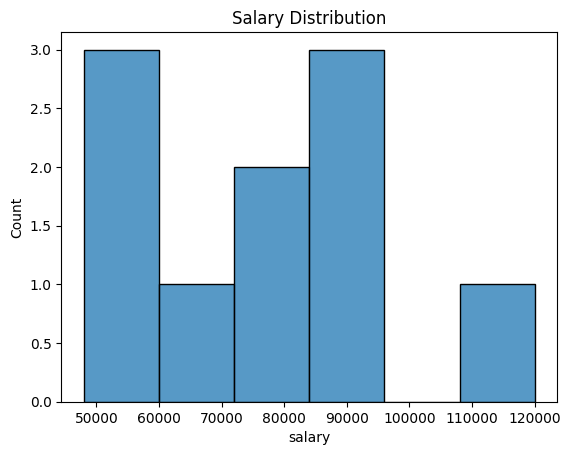

,count
department,
IT,4
HR,3
Finance,3


In [19]:
# Univariate Analysis

# Salary Distribution
plt.figure()
sns.histplot(df["salary"], bins=6)
plt.title("Salary Distribution")
plt.show()

# Department Distribution
df["department"].value_counts()

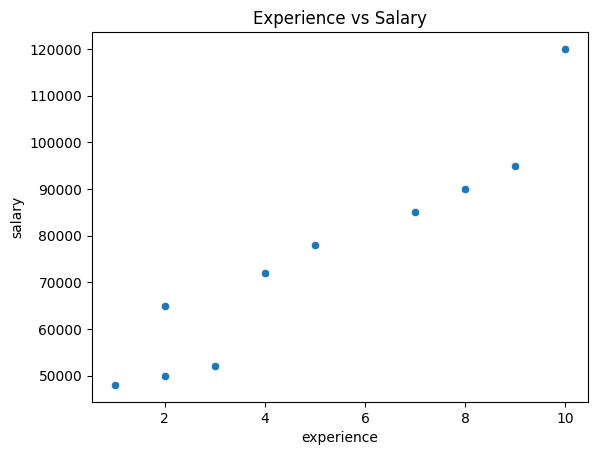

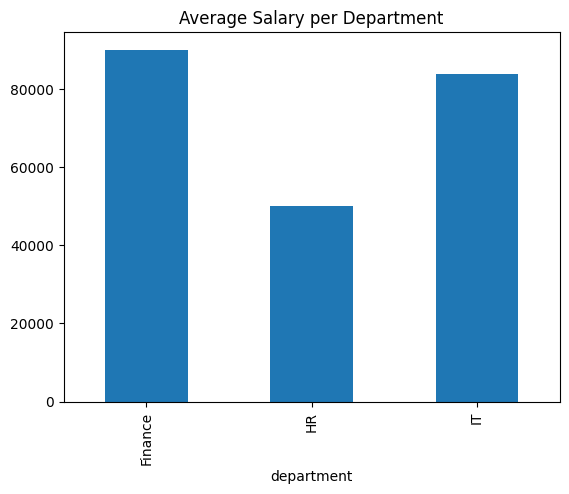

In [20]:
# Bivariate Analysis

# Experience vs Salary
plt.figure()
sns.scatterplot(x="experience", y="salary", data=df)
plt.title("Experience vs Salary")
plt.show()   # Salary strongly increases with experience.

# Avg Salary per Department
df.groupby("department")["salary"].mean()   # Finance department has the highest average salary. Employees earning above average are primarily from IT and Finance.

# Bar plot:
plt.figure()
df.groupby("department")["salary"].mean().plot(kind="bar")
plt.title("Average Salary per Department")
plt.show()

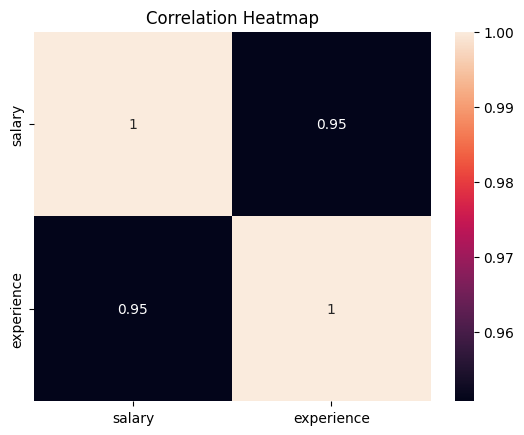

In [22]:
# Correlation Heatmap

plt.figure()
sns.heatmap(df[["salary","experience"]].corr(), annot=True)
plt.title("Correlation Heatmap")   # Correlation between salary and experience is positive.
plt.show()

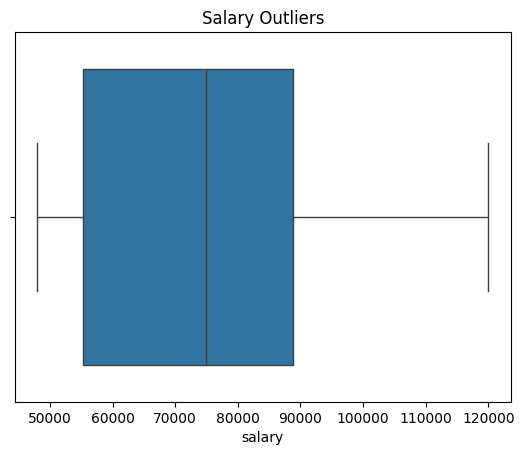

   employee_id department       city  salary  experience
0          101         IT      Delhi   65000           2
1          102         HR     Mumbai   48000           1
2          103         IT      Delhi   72000           4
3          104    Finance  Bangalore   90000           8
4          105         HR     Mumbai   52000           3
5          106    Finance      Delhi   85000           7
6          107         IT  Bangalore   78000           5
7          108         HR      Delhi   50000           2
8          109    Finance     Mumbai   95000           9
9          110         IT      Delhi  120000          10


In [26]:
# Outlier Detection

# Boxplot:
plt.figure()
sns.boxplot(x=df["salary"])
plt.title("Salary Outliers")   # One potential high-end salary acts as mild outlier.
plt.show()   # if there will be outlier it'll be shown by a dot. Whiskers = the “lines”(left line and right line) that extend from the box to show the normal range of data.
# May be there can be calculation mistakes, focus on concept/understanding:  Q1 = 52,000 (25th percentile), Q2/Median = 75,000 (middle value), Q3 = 90,000 (75th percentile), IQR = Q3 − Q1 = 90,000 − 52,000 = 38,000, Lower Bound = Q1 − 1.5×IQR = 52,000 − 57,000 = −5,000, Upper Bound = Q3 + 1.5×IQR = 90,000 + 57,000 = 147,000, Lower Whisker = min value ≥ Lower Bound = 48,000, Upper Whisker = max value ≤ Upper Bound = 120,000.   Now see in box plot.
# Bounds = limits, Whiskers = actual data within limits. See that box plot(left lines show whiskers, not bounds)

# Optional IQR removal:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_clean = df[(df["salary"] >= lower) & (df["salary"] <= upper)]
print(df_clean)


In [10]:
# Feature Creation

# Salary after tax (20%)
df["salary_after_tax"] = df["salary"] * 0.8

# High income flag
df["high_income"] = df["salary"] > df["salary"].mean()

# Experience level category
df["experience_level"] = pd.cut(
    df["experience"],
    bins=[0,3,6,10],   # By default: The right value is included, The left value is excluded. ex.: ranges become: (0, 3], (3, 6], (6, 10]
    labels=["Junior","Mid","Senior"]   # Most employees fall into junior and senior level experience category.
)

print(df)

   employee_id department       city  salary  experience  salary_after_tax  \
0          101         IT      Delhi   65000           2           52000.0   
1          102         HR     Mumbai   48000           1           38400.0   
2          103         IT      Delhi   72000           4           57600.0   
3          104    Finance  Bangalore   90000           8           72000.0   
4          105         HR     Mumbai   52000           3           41600.0   
5          106    Finance      Delhi   85000           7           68000.0   
6          107         IT  Bangalore   78000           5           62400.0   
7          108         HR      Delhi   50000           2           40000.0   
8          109    Finance     Mumbai   95000           9           76000.0   
9          110         IT      Delhi  120000          10           96000.0   

   high_income experience_level  
0        False           Junior  
1        False           Junior  
2        False              Mid  
3    

## Final Insights

Salary distribution is slightly right-skewed due to higher-end salaries.

Finance department has the highest average salary.

HR has the lowest salary range.

Salary strongly increases with experience.

Correlation between salary and experience is positive.

One potential high-end salary acts as mild outlier.

Most employees fall into junior and senior level experience category.

Employees earning above average are primarily from IT and Finance.

Delhi has highest concentration of employees.

Variability in Finance salaries is higher than HR.